# Tugas Besar IF3270 Pembelajaran Mesin
## Feedforward Neural Network

**Nama Anggota:**
- 13523135 - Ahmad Syafiq
- 13523152 — Muhammad Kinan Arkansyaddad
- 13523162 — Fachriza Ahmad Setiyono

**Kelas:** 3

---

## 0. Import Libraries & Load Data

In [ ]:
!pip install -r ../requirements.txt

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score
from models.nn import FFNN

# tambahkan import lainnya sesuai kebutuhan

RANDOM_STATE = 42

In [9]:
# Load dataset
file_path = '../data/datasetml_2026.csv'

train_df = pd.read_csv(file_path)

print("Train shape:", train_df.shape)

Train shape: (10000, 12)


---
## 1. Exploratory Data Analysis (EDA)

> **Tujuan:** Memahami data secara mendalam sebelum preprocessing dan modeling.
> **Requirement:** Minimal **3 visualisasi** dengan **3 pertanyaan** (1 per visualisasi).

### 1.1 Gambaran Umum Dataset

In [10]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [16]:
TARGET_COL = 'placement_status'
NUM_COLS = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']
ORDINAL_COLS = ['college_tier', 'university_ranking_band']
CATEGORICAL_COLS = ['country', 'specialization', 'industry']

In [ ]:
train_df.describe(include='all')

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cgpa,10000.0,NaN,NaN,NaN,6.99829,0.802606,4.0,6.461928,6.997924,7.536865,10.0
backlogs,10000.0,NaN,NaN,NaN,1.2481,1.149904,0.0,0.0,1.0,2.0,6.0
college_tier,10000,3,Tier 2,3993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,10000,5,Germany,2057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
university_ranking_band,10000,3,300+,4075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internship_count,10000.0,NaN,NaN,NaN,1.4993,1.20289,0.0,1.0,1.0,2.0,5.0
aptitude_score,10000.0,NaN,NaN,NaN,69.877531,14.700532,30.0,59.880399,70.097368,80.213934,100.0
communication_score,10000.0,NaN,NaN,NaN,65.1586,14.740446,30.0,55.112244,65.006484,75.277248,100.0
specialization,10000,5,Data Science,2036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,10000,6,Consulting,1739,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [18]:
# Distribusi kelas target
print(train_df[TARGET_COL].value_counts())

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


### 1.2 Visualisasi 1 — Distribusi Kelas

*Pertanyaan:* Apakah proporsi kelas pada dataset seimbang atau imbalanced?

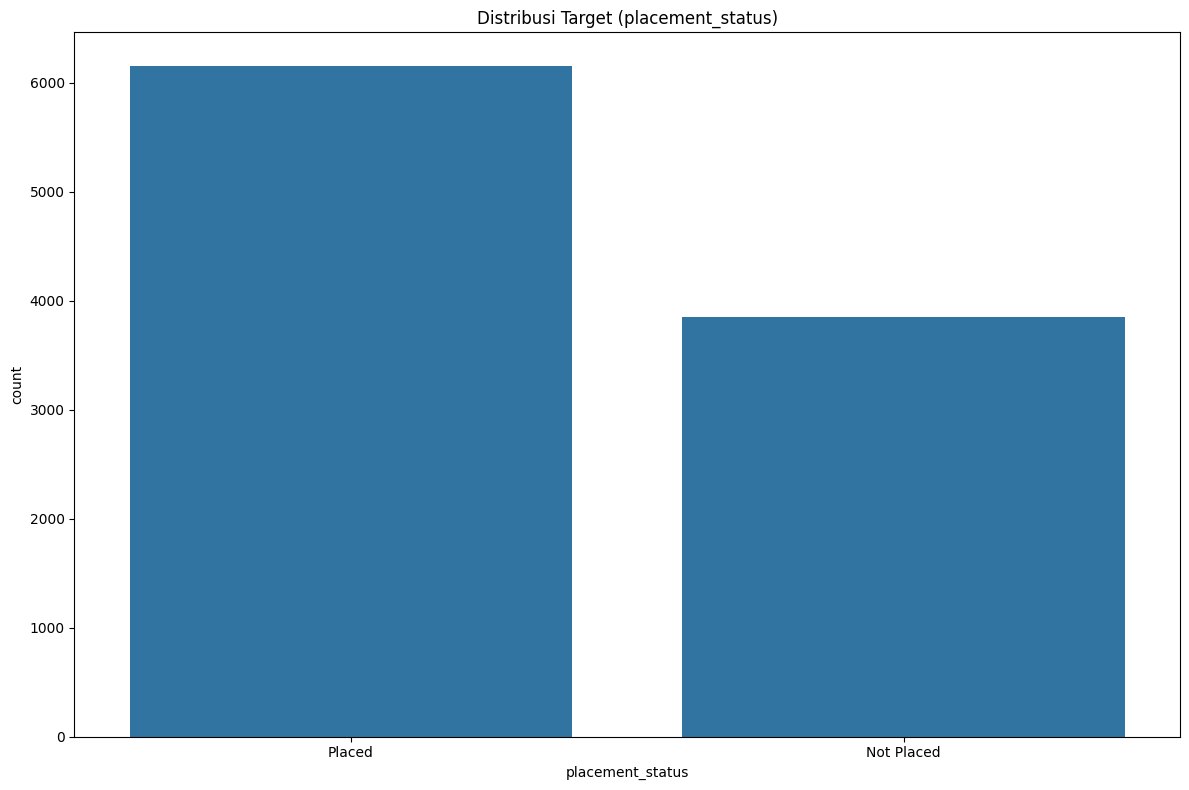

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(12, 8))

sns.countplot(data=train_df, x=TARGET_COL, ax=axes)
axes.set_title('Distribusi Target (placement_status)')

plt.tight_layout()
plt.show()

**Analisis:** a

### 1.3 Visualisasi 2 — *Outlier* dataset

*Pertanyaan:* Apakah ada *outlier* pada target dataset terhadap fitur dataset?

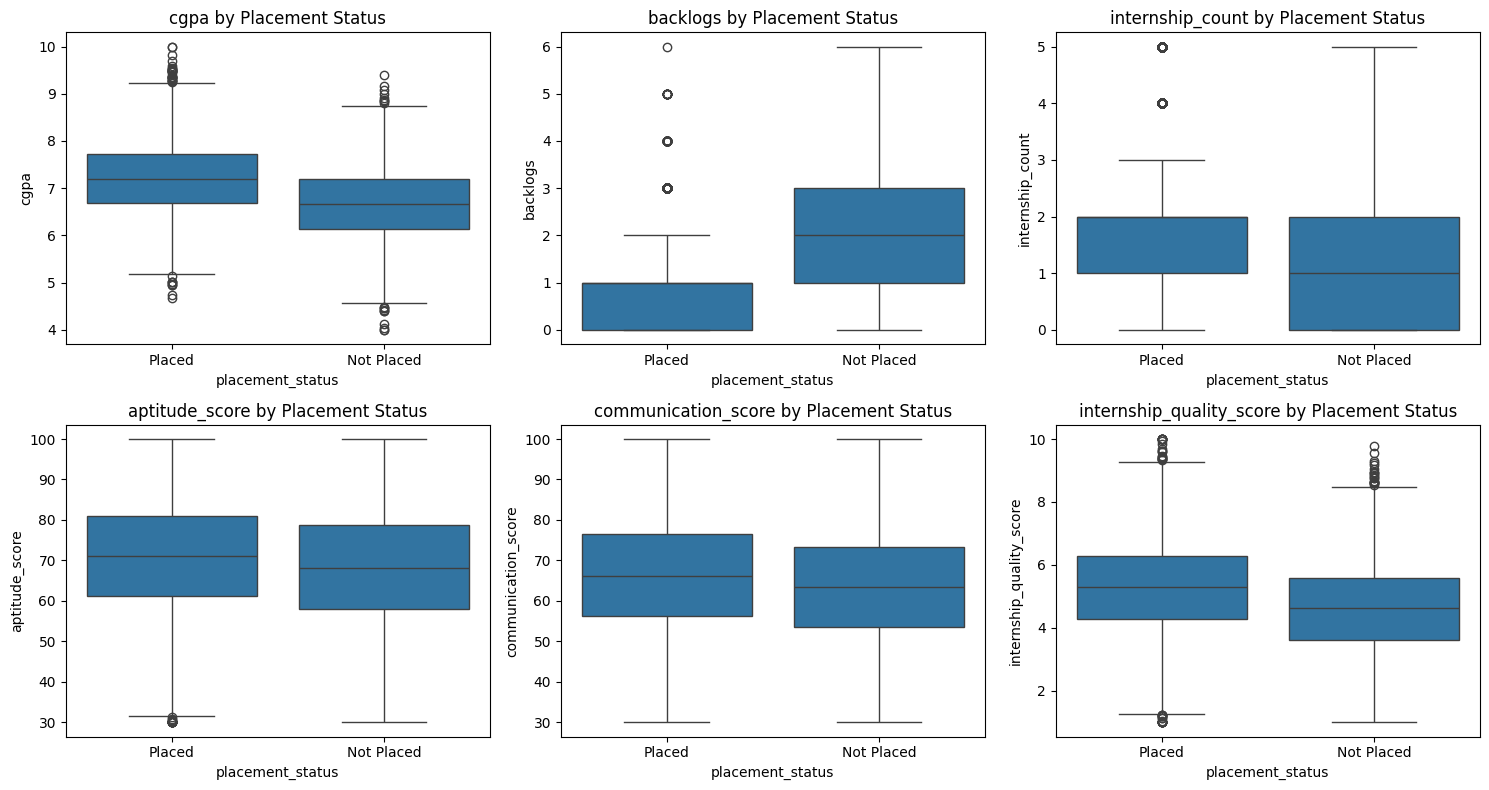

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), NUM_COLS):
    sns.boxplot(data=train_df, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(f'{col} by Placement Status')
plt.tight_layout()
plt.show()

**Analisis:** Dari diagram *boxplot* .

### 1.4 Visualisasi 2 — Hubungan Kolom Kategorikal dengan Kelas Target

*Pertanyaan:* Bagaimana korelasi antara kelas target dengan kolom kategorikal?

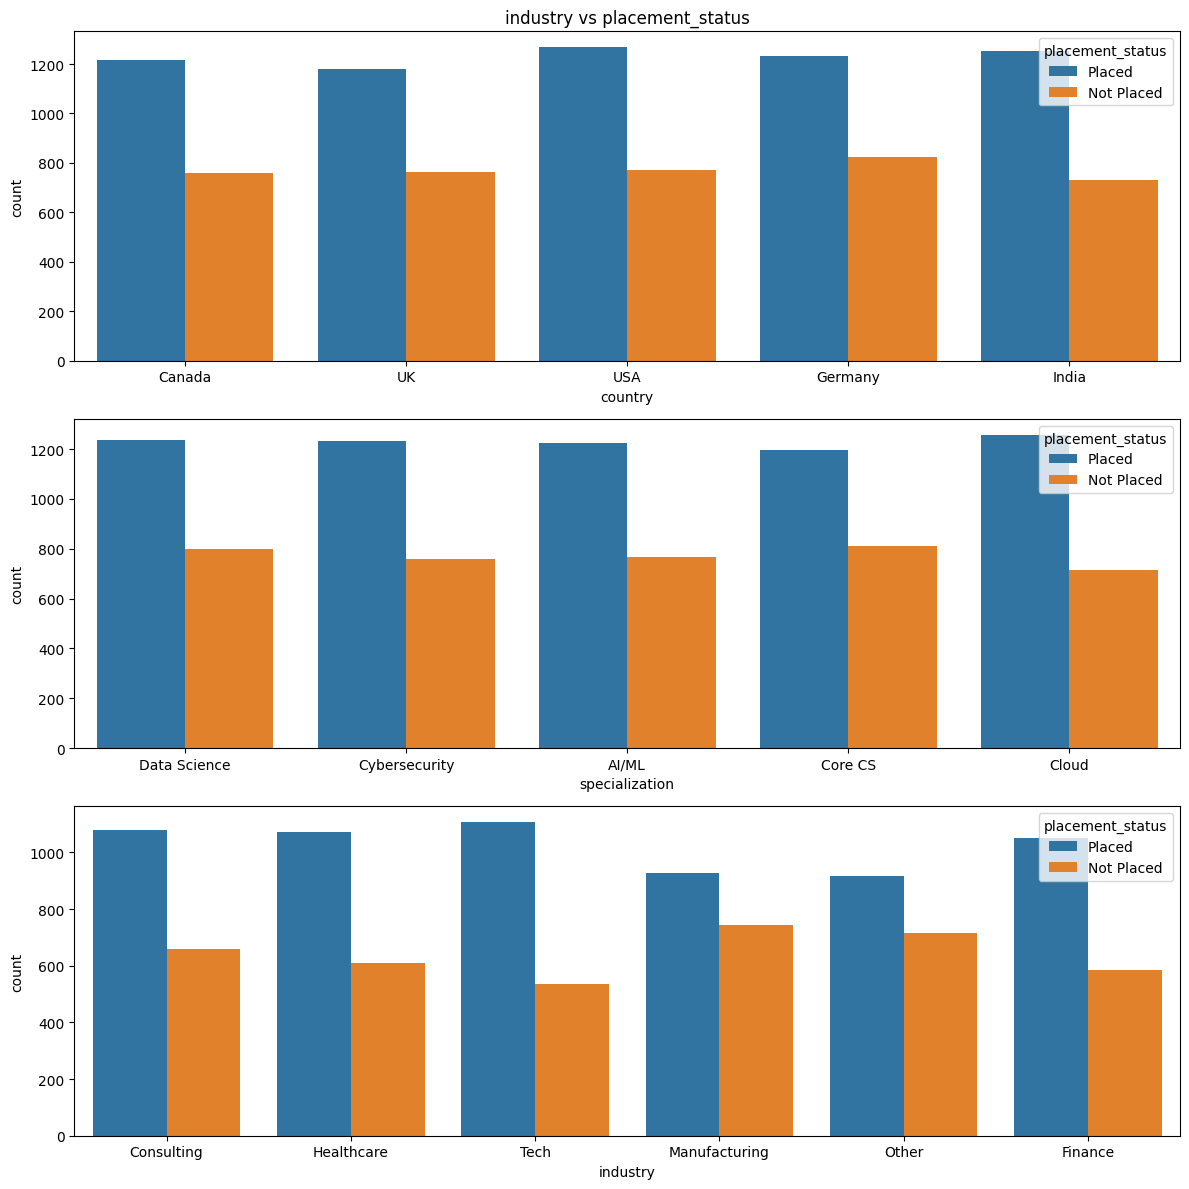

In [22]:
fig, axes = plt.subplots(len(CATEGORICAL_COLS), 1, figsize=(12, 12))


for i in range(len(CATEGORICAL_COLS)):
    sns.countplot(data=train_df, x=CATEGORICAL_COLS[i], hue=TARGET_COL, ax=axes[i])
    axes[0].set_title(f'{CATEGORICAL_COLS[i]} vs {TARGET_COL}')

plt.tight_layout()
plt.show()

**Analisis:**
Dari grafik tersebut, terlihat 

### 1.5 Heatmap Korelasi antar Fitur Numerik

*Pertanyaan:* Bagaimana korelasi antara fitur numerik dataset?

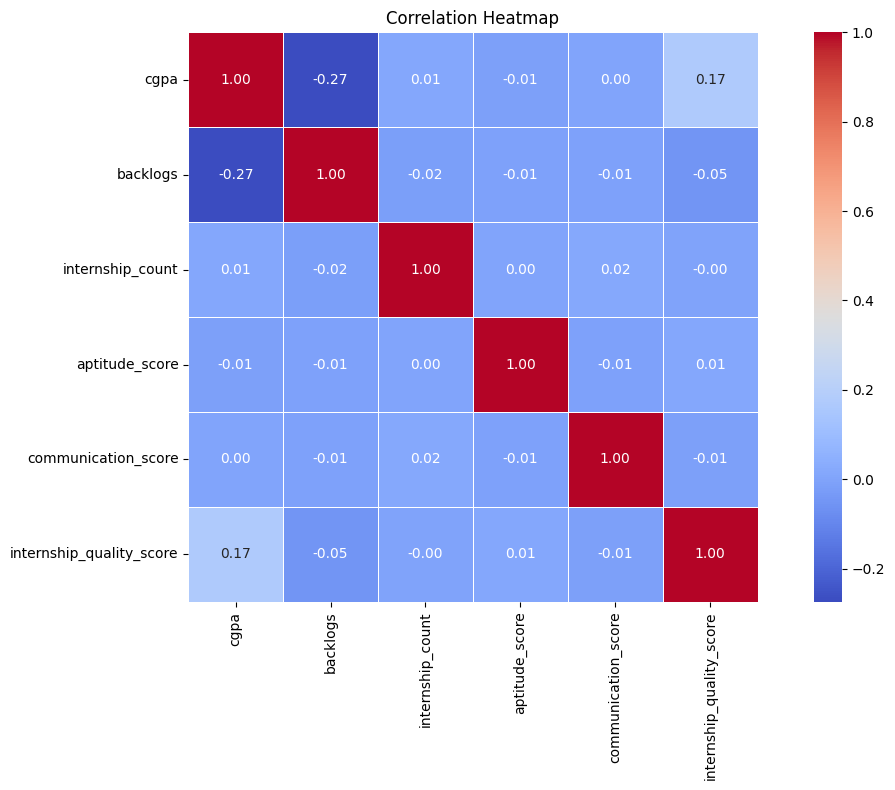

In [23]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df[NUM_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Analisis:** *Heatmap* menunjukkan

---
## 2. Data Cleaning and Preprocessing

> **Tujuan:** Menyiapkan data untuk training model.
> **Requirement:** Sertakan **penjelasan** untuk setiap langkah.

> ⚠️ **Ingat:** Fit transformer **hanya pada training data**, lalu transform train dan test secara terpisah untuk menghindari data leakage.

In [26]:
# TARGET_COL, NUM_COLS, ORDINAL_COLS, CATEGORICAL_COLS sudah terdefinisi

print("Categorical:", CATEGORICAL_COLS)
print("Numerical:  ", NUM_COLS)

X = train_df.drop(TARGET_COL, axis=1)
y = train_df[TARGET_COL]


Categorical: ['country', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


### 2.2 Handling Outliers

**Penjelasan:** *[Apakah Anda menangani outlier? Metode dan alasannya?]*

In [ ]:
# for col in NUM_COLS:
#     Q1 = train[col].quantile(0.25)
#     Q3 = train[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     # Menghitung jumlah yang terdampak (opsional untuk log)
#     outliers = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
#     print(f" - {col}: {outliers} outlier dideteksi")

#     # Clipping data train dan test menggunakan bound dari train
#     train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
#     test[col]  = test[col].clip(lower=lower_bound, upper=upper_bound)

### 2.3 Encoding Fitur Kategorik

**Penjelasan:** *[Metode encoding yang dipilih dan alasannya]*

In [32]:
# encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

college_tiers = ['Tier 3', 'Tier 2', 'Tier 1']
ranking_bands = ['300+', '100-300', 'Top 100']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[college_tiers, ranking_bands]))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 7. Combine all steps into a ColumnTransformer Preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_COLS),
    ('ord', ordinal_pipeline, ORDINAL_COLS),
    ('cat', nominal_pipeline, CATEGORICAL_COLS)
])

### 2.4 Feature Scaling

**Penjelasan:** *[Apakah perlu scaling? Untuk model apa? Metode yang dipilih?]*

### 2.5 (Opsional) Feature Engineering / Selection

### 2.6 Train-Validation Split

In [28]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (8000, 11) | y_train: (8000,)
X_val:   (2000, 11) | y_val:   (2000,)


In [49]:
X_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

---
## 3. Modeling and Validation

> **Metrik utama:** Macro F1-Score

In [75]:
results = {}

HIDDEN_NODES = 4
LR = 0.01
EPOCHS = 15
BATCH_SIZE = 16


def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred_probs = model.predict(X_val)
    y_pred = (y_pred_probs > 0.5).astype(int)
    print(f"{'='*30}")
    print(f"  {model_name}")
    print(f"{'='*30}")

    print(classification_report(y_val, y_pred,
                                target_names=['Rejected (0)', 'Approved (1)']))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

### 3.1 Custom Model


In [ ]:
custom_model = FFNN(
    layers_config=[X_preprocessed.shape[1], HIDDEN_NODES, 1],
    activations='sigmoid',
    loss_function='bce',
    init_method='he',
    random_state=RANDOM_STATE
)

custom_history = custom_model.fit(
    X_preprocessed, y_train.reshape(-1, 1),
    X_val_preprocessed, y_val.reshape(-1, 1),
    batch_size=BATCH_SIZE,
    lr=LR,
    epochs=EPOCHS,
    solver='sgd',
    verbose=True
)


results["Custom FFNN"] = evaluate_model(custom_model, X_val_preprocessed, y_val, "Custom FFNN")

Epoch 1/15
500/500 [------------------------------] - loss: 0.6810 - val_loss: 0.6528
Epoch 2/15
500/500 [------------------------------] - loss: 0.6439 - val_loss: 0.6381
Epoch 3/15
500/500 [------------------------------] - loss: 0.6281 - val_loss: 0.6213
Epoch 4/15
500/500 [------------------------------] - loss: 0.6087 - val_loss: 0.6007
Epoch 5/15
500/500 [------------------------------] - loss: 0.5871 - val_loss: 0.5794
Epoch 6/15
500/500 [------------------------------] - loss: 0.5658 - val_loss: 0.5599
Epoch 7/15
500/500 [------------------------------] - loss: 0.5471 - val_loss: 0.5434
Epoch 8/15
500/500 [------------------------------] - loss: 0.5320 - val_loss: 0.5312
Epoch 9/15
500/500 [------------------------------] - loss: 0.5207 - val_loss: 0.5220
Epoch 10/15
500/500 [------------------------------] - loss: 0.5125 - val_loss: 0.5157
Epoch 11/15
500/500 [------------------------------] - loss: 0.5065 - val_loss: 0.5113
Epoch 12/15
500/500 [------------------------------]

**Analisis Kinerja Custom FFNN:**  
*[Bahas precision, recall, f1 per kelas. Jelaskan kelebihan dan kekurangan Bagging/RF.]*

### 3.2 SKLearn


In [ ]:
sk_model = MLPClassifier(
    hidden_layer_sizes=(HIDDEN_NODES,),
    activation='logistic',
    solver='sgd',
    batch_size=BATCH_SIZE,
    learning_rate_init=LR,
    learning_rate='constant',
    max_iter=EPOCHS,
    random_state=RANDOM_STATE,
    verbose=True,
    momentum=0.0
)

sk_model.fit(X_preprocessed, y_train)
results["SKLearn MLP"] = evaluate_model(sk_model, X_val_preprocessed, y_val, "SKLearn MLP")

Iteration 1, loss = 0.66761967
Iteration 2, loss = 0.65545305
Iteration 3, loss = 0.64271037
Iteration 4, loss = 0.62582485
Iteration 5, loss = 0.60556715
Iteration 6, loss = 0.58374450
Iteration 7, loss = 0.56314283
Iteration 8, loss = 0.54554318
Iteration 9, loss = 0.53156923
Iteration 10, loss = 0.52103254
Iteration 11, loss = 0.51314662
Iteration 12, loss = 0.50750426
Iteration 13, loss = 0.50334385
Iteration 14, loss = 0.50029247
Iteration 15, loss = 0.49801231
  SKLearn MLP
              precision    recall  f1-score   support

Rejected (0)       0.73      0.61      0.66       769
Approved (1)       0.78      0.86      0.82      1231

    accuracy                           0.76      2000
   macro avg       0.75      0.73      0.74      2000
weighted avg       0.76      0.76      0.76      2000

>>> Macro F1-Score: 0.7406



C:\Users\rizac\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


### 3.5 Perbandingan Semua Model

In [79]:
# Tabel perbandingan
results_df = (
    pd.DataFrame.from_dict(results, orient='index', columns=['Macro F1-Score'])
    .sort_values('Macro F1-Score', ascending=False)
)
print(results_df.to_string())

# Bar chart
plt.figure(figsize=(8, 4))
results_df['Macro F1-Score'].plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Macro F1-Score')
plt.title('Perbandingan Macro F1-Score Semua Model')
plt.xlim(0, 1)
for i, v in enumerate(results_df['Macro F1-Score']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

TypeError: '<' not supported between instances of 'FFNN' and 'MLPClassifier'

**Kesimpulan Perbandingan:**  
Peringkat tertinggi dipenuhi oleh model *boosting* dan *stacking*. *Boosting* mampu memanfaatkan *weak learner* untuk mendapatkan hipotesis yang cukup baik. Namun, algoritma yang digunakan adalah *gradient boosting* milik sklearn yang waktu latihnya relatif lebih lama dari yang lain. Stacking dengan beberapa algoritma *boosting* yang efisien mampu bersaing.

Secara umum, model *boosting* dapat bekerja dengan baik pada dataset dengan bias atau varians yang tinggi. Stacking juga bisa digunakan pada data yang kompleks yang memerlukan banyak tipe model untuk mendapat pola data.

---
## 4. Error Analysis

> **Tujuan:** Memahami pola kegagalan model dan menemukan peluang perbaikan.

### 4.1 Confusion Matrix

In [ ]:
best_model   = gb_model # TODO: ganti dengan model terbaik Anda
y_pred_best  = best_model.predict(X_val)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred_best),
    display_labels=['Rejected (0)', 'Approved (1)']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Gradient Boost')  # TODO: isi nama model
plt.tight_layout()
plt.show()

**Analisis Confusion Matrix:**  
*Confusion Matrix* menunjukkan beberapa prediksi yang salah, yaitu 196 FP dan 369 FN.

Dalam konteks peminjaman utang, FP (menyetujui yang ditolak) lebih merugikan dibanding FN. Ini karena kerugian dari FN hanya berupa potensi bunga yang hilang. Kerugian FP bisa berupa kehilangan pinjaman, bunga, hingga rusaknya reputasi perusahaan.

### 4.2 Analisis Sampel yang Salah Diklasifikasikan

In [ ]:
# Snippet: membuat dataframe error
# -------------------------------------------------------
y_val_arr  = y_val.reset_index(drop=True)
X_val_arr  = X_val.reset_index(drop=True)
pred_arr   = pd.Series(y_pred_best, name='y_pred')
#
error_mask = y_val_arr != pred_arr
error_df = X_val_arr[error_mask].copy()
error_df['y_true'] = y_val_arr[error_mask].values
error_df['y_pred'] = pred_arr[error_mask].values
#
print(f"Total error: {len(error_df)} / {len(y_val)} sampel ({len(error_df)/len(y_val)*100:.1f}%)")
# -------------------------------------------------------
# TODO: Analisis error — cari pola
# Pertanyaan panduan:
#   - Apakah error terkonsentrasi pada credit_score atau income tertentu?
#   - Apakah previous_loan_defaults berkorelasi dengan jenis error?
#   - Apakah ada home_ownership type yang lebih sering salah?

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(12, 8))
plt.hist(error_df["credit_score"], bins=50)
#plt.hist(data=error_df, x='credit_score', ax=axes)
axes.set_title('Distribusi Error Credit Score')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(12, 8))
plt.hist(error_df["person_income"], bins=50)
#plt.hist(data=error_df, x='credit_score', ax=axes)
axes.set_title('Distribusi Error Credit Score')

plt.tight_layout()
plt.show()

**Analisis:** Error prediksi sebesar 7.8%. Untuk credit score terfokus pada spektrum tengah ke atas, tapi berlaku sebaliknya untuk income.

### 4.3 Feature Importance

In [ ]:
# Snippet: feature importance dari tree-based model
# -------------------------------------------------------
model_with_fi = gb_model  # atau gb_model
#
importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': model_with_fi.feature_importances_
}).sort_values('Importance', ascending=False)
#
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()
# -------------------------------------------------------

# TODO: Visualisasikan feature importance

**Analisis Feature Importance:**  
Fitur yang paling penting adalah keberhasilan peminjam dalam peminjaman sebelumnya. Secara bisnis, ini sangat masuk akal karena peminjam yang berhasil melunasi peminjaman sebelumnya lebih terpercaya dari yang tidak.

Fitur seperti *home ownership* tidak memeliki kepentingan dalam model ini, sehingga bisa dihilangkan.

### 4.4 Kesimpulan Error Analysis

Model yang dipilih masih menghasilkan kesalahan sebesar 7.8%. Untuk memperbaiki akurasi model, bisa dilakukan *feature engineering* yang lebih efektif. Selain itu, perencanaan model ensembel dan hyperparameter tuning yang lebih baik juga dapat membantu hasil akurasi model.

---
## 5. Submisi Kaggle

> ⚠️ **PENTING:**
> - Jangan gunakan `sample_submission.csv` sebagai submisi utama.
> - Pastikan hasil prediksi **reproducible** dari notebook ini.
> - Format: kolom `person_id` dan `loan_status`.

In [ ]:
final_model = gb_model # TODO: model dengan Macro F1 tertinggi

test_predictions = final_model.predict(X_test_final)

submission = pd.DataFrame({
    'person_id':   test_df[ID_COL],
    'loan_status': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"Saved! Shape: {submission.shape}")
print(f"Distribusi prediksi:\n{submission['loan_status'].value_counts()}")
submission.head(10)

**Catatan Submisi:**
| | |
|---|---|
| Model final | GradientBoost (gb_model) |
| Macro F1 — Validation Set | 0.881834 |
| Macro F1 — Kaggle Public LB | 0.89301 |
| Macro F1 — Kaggle Private LB | - (private belum visible) |

---
## 6. Kesimpulan Keseluruhan

Model yang terbaik adalah Stacking dan Gradient Boosting, namun yang meraih skor tertinggi di Kaggle adalah Gradient Boosting. Model dilatih menggunakan hyperparameter tuning via randomized search.

EDA menunjukkan dataset yang digunakan bersifat *imbalanced*. Outlier juga ditemukan dengan histplot, yang nantinya akan dihilangkan dengan metode IQR. Melalui diagram bar juga ditemukan korelasi antar status peminjaman dengan tipe kepemilikan rumah. Sedangkan hasil analisis heatmap tidak terlalu membantu karena tidak ada korelasi antar kolom numerik yang penting.

Model yang dipilih menghasilkan error sebesar 7.8%. Dengan error analysis, untuk selanjutnya bisa dilakukan *feature engineering* yang lebih efektif dan pemilihan model ensembel serta hyperparameter tuning yang lebih baik.